In [21]:
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# 1. Clean and Encode (Essential for XGBoost)
# This handles the 'text to numbers' conversion automatically
X = pd.get_dummies(df.drop('price', axis=1))
y = df['price']

# 2. Force types to float to prevent "Masked Array" errors
X = X.astype(float)
y = y.astype(float)

# 3. Standard Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Fit the model
model = XGBRegressor(n_estimators=100, learning_rate=0.1)
model.fit(X_train, y_train)

# 5. One Final Prediction
sample = X_test.head(1)
actual = y_test.iloc[0]
pred = model.predict(sample)[0]

print(f"--- PROJECT COMPLETE ---")
print(f"Actual Price: ${actual} | Predicted: ${pred:.2f}")

--- PROJECT COMPLETE ---
Actual Price: $32870.0 | Predicted: $25793.56


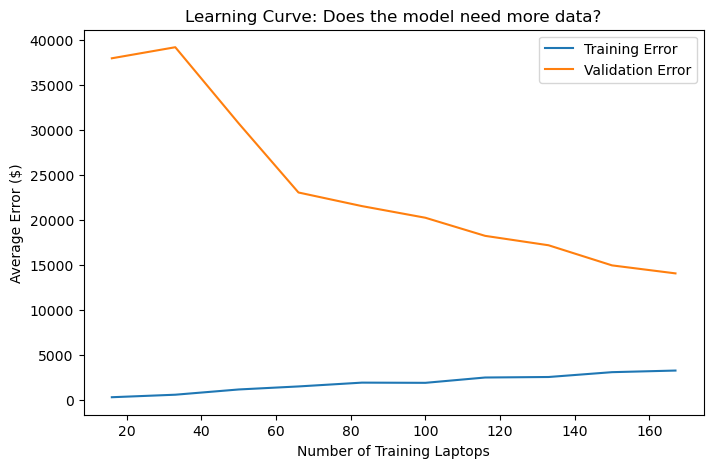

In [22]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

# Calculate training and test scores for different training set sizes
train_sizes, train_scores, test_scores = learning_curve(
    model, X, y, cv=5, scoring='neg_mean_absolute_error', 
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Error')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Validation Error')
plt.title('Learning Curve: Does the model need more data?')
plt.xlabel('Number of Training Laptops')
plt.ylabel('Average Error ($)')
plt.legend()
plt.show()

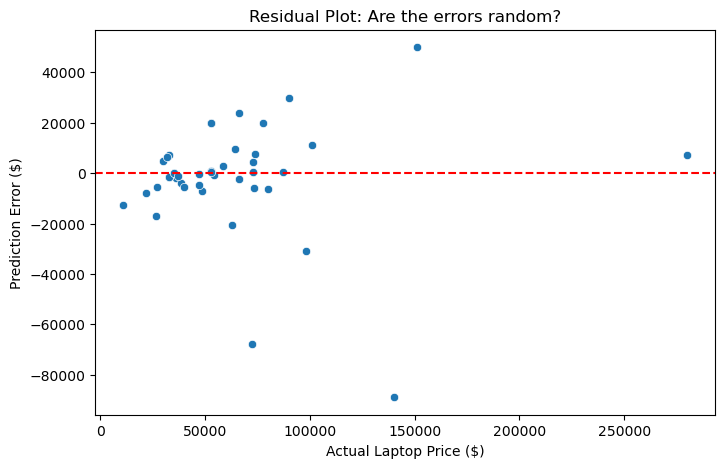

In [23]:
import seaborn as sns

# Calculate the errors (Residuals = Actual - Predicted)
predictions = model.predict(X_test)
residuals = y_test - predictions

# Plot Actual Prices vs the Errors
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot: Are the errors random?')
plt.xlabel('Actual Laptop Price ($)')
plt.ylabel('Prediction Error ($)')
plt.show()